# Matching the detection window to the transient-change duration

Two synthetic-data comparisons for ODMD-CPD, each plotted as the **detection
statistic over time, below the signal**. A *transient* change is a temporary
regime shift — here a **level pulse**: a benign sinusoidal carrier on which the
signal jumps by `AMP` for `duration` samples, then reverts. A low-rank linear
model cannot reconstruct the shifted level, so the reconstruction-error score
fires.

The rolling OnlineDMD learning window is held fixed (constant model quality);
only the detection windows `ref_size = test_size` change.

1. **Fixed duration, varying window** — one transient, several window sizes
   overlaid. The window matched to the duration gives the strongest, cleanest
   statistic; an oversized window dilutes the change.
2. **Fixed window, varying duration** — several transients of different
   durations, one window. The statistic grows as the duration approaches the
   window and saturates once the transient fills it.

In [3]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from river.decomposition import OnlineDMD
from river.preprocessing import Hankelizer

sys.path.append("../")
from reshift.chdsubid import SubIDChangeDetector
from reshift.rolling import Rolling

In [4]:
# Fixed configuration
LEARN_W = (
    600  # rolling OnlineDMD window (held constant -> constant model quality)
)
HN = 20  # time-delay embedding order
R = 2  # DMD rank
CARRIER_F = 0.05  # benign carrier frequency
AMP = 1.0  # transient level-shift amplitude
SIGMA = 0.01  # measurement noise std


def make_signal(
    n: int,
    pulses: list[tuple[int, int]],
    seed: int = 0,
) -> np.ndarray:
    """Sinusoidal carrier with level pulses. `pulses` = list of (onset, duration)."""
    rng = np.random.default_rng(seed)
    x = np.sin(2 * np.pi * CARRIER_F * np.arange(n)) + rng.normal(0, SIGMA, n)
    for onset, dur in pulses:
        x[onset : onset + dur] += AMP
    return x


def score_over_time(x: np.ndarray, det_win: int) -> np.ndarray:
    """Run ODMD-CPD over the stream and return the per-sample score trace."""
    odmd = Rolling(
        OnlineDMD(
            r=R,
            initialize=LEARN_W,
            w=1.0,
            exponential_weighting=False,
            seed=42,
        ),
        LEARN_W + 1,
    )
    det = SubIDChangeDetector(
        odmd,
        ref_size=det_win,
        test_size=det_win,
        grace_period=LEARN_W + det_win + 1,
        start_soon=True,
    )
    pipe = Hankelizer(HN) | det
    s = np.zeros(len(x))
    for i, xi in enumerate(
        pd.DataFrame(x.reshape(-1, 1)).to_dict(orient="records"),
    ):
        try:
            s[i] = pipe.score_one(xi)
        except ZeroDivisionError:  # degenerate reference (numerical fragility)
            s[i] = s[i - 1] if i else 0.0
        pipe.learn_one(xi)
    return np.nan_to_num(s)


def shade(ax: plt.Axes, pulses: list[tuple[int, int]]) -> None:
    """Shade each transient interval on an axis."""
    for onset, dur in pulses:
        ax.axvspan(onset, onset + dur, color="C1", alpha=0.2)

## 1. Fixed transient duration, varying window size

One transient of duration 250; detection windows of 125 (half), 250 (matched)
and 500 (double). The matched window holds the largest sustained statistic over
the transient; the oversized window dilutes it (lower, smeared).

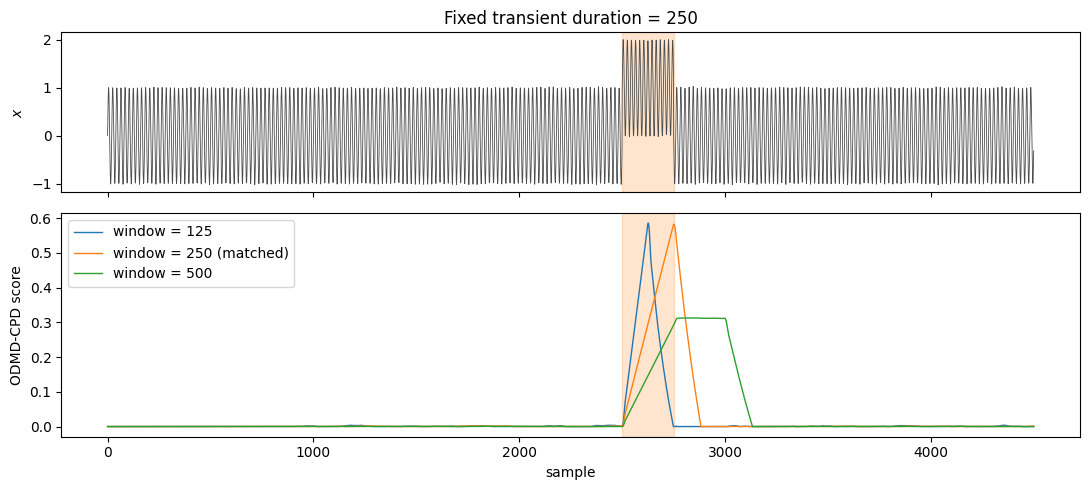

In [5]:
N1 = 4500
DURATION = 250
T0 = 2500
PULSES1 = [(T0, DURATION)]
WINDOWS = [125, 250, 500]

x1 = make_signal(N1, PULSES1)
scores1 = {w: score_over_time(x1, w) for w in WINDOWS}

fig, (ax_sig, ax_sc) = plt.subplots(
    2,
    1,
    figsize=(11, 5),
    sharex=True,
    height_ratios=[1, 1.4],
)
ax_sig.plot(x1, lw=0.6, color="0.3")
shade(ax_sig, PULSES1)
ax_sig.set(ylabel="$x$", title=f"Fixed transient duration = {DURATION}")

for w in WINDOWS:
    label = f"window = {w}" + (" (matched)" if w == DURATION else "")
    ax_sc.plot(scores1[w], lw=1.0, label=label)
shade(ax_sc, PULSES1)
ax_sc.set(xlabel="sample", ylabel="ODMD-CPD score")
ax_sc.legend(loc="upper left")
fig.tight_layout()

## 2. Fixed window size, varying transient duration

Window fixed at 250; three transients of duration 100, 250 and 500. The
statistic is weak for the short transient (it only partly fills the window),
peaks when the duration matches the window, and saturates for the long one.

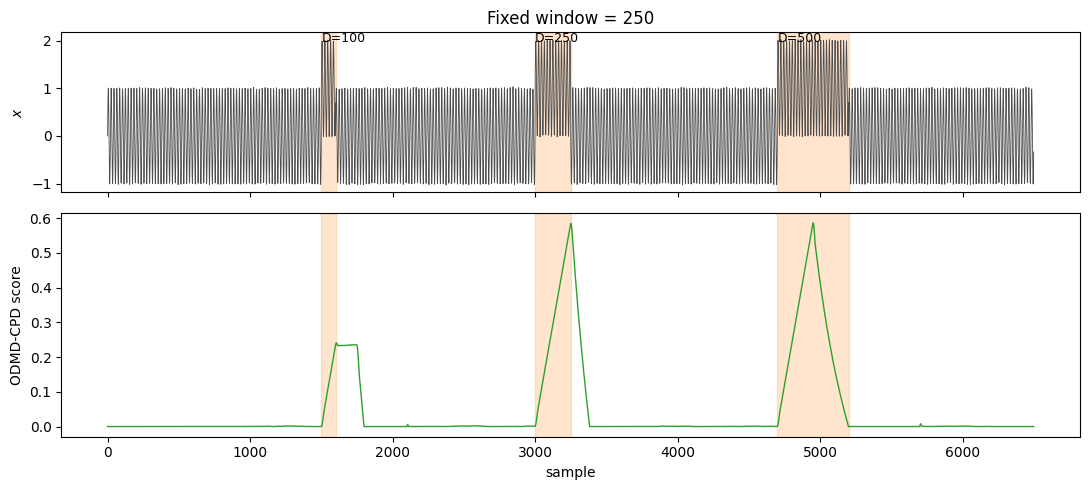

In [6]:
N2 = 6500
WINDOW_FIXED = 250
PULSES2 = [(1500, 100), (3000, 250), (4700, 500)]

x2 = make_signal(N2, PULSES2)
score2 = score_over_time(x2, WINDOW_FIXED)

fig, (ax_sig, ax_sc) = plt.subplots(
    2,
    1,
    figsize=(11, 5),
    sharex=True,
    height_ratios=[1, 1.4],
)
ax_sig.plot(x2, lw=0.6, color="0.3")
shade(ax_sig, PULSES2)
for onset, dur in PULSES2:
    ax_sig.annotate(
        f"D={dur}",
        (onset, ax_sig.get_ylim()[1]),
        fontsize=9,
        va="top",
    )
ax_sig.set(ylabel="$x$", title=f"Fixed window = {WINDOW_FIXED}")

ax_sc.plot(score2, lw=1.0, color="C2")
shade(ax_sc, PULSES2)
ax_sc.set(xlabel="sample", ylabel="ODMD-CPD score")
fig.tight_layout()
plt.show()